1.1. Imports

In [1]:
import json
import pandas as pd
import numpy as np
from collections import Counter
import statsmodels.formula.api as smf
from datetime import datetime
import math


1.2. Constant Declarations

In [ ]:
AITA_FILE = "D://Python/AITA_data/amitheasshole_submission.json"
TOTAL_N_LINES = 671621
parameter_setting = '300_5_0.25_average.txt'
variables = [l.strip('\n').split() for l in open('./variables/' + parameter_setting).readlines()]
variant_to_variable = {w : '|'.join(V) for i,V in enumerate(variables) for w in V}
print('n variants', len(variant_to_variable), 'n variables', len(variables))
#
plausHits = json.loads(open('./hedgeDataPlausibilityShields.json').read())
demoHits = json.loads(open('./demo_data_strategy2.json').read()) #Referenced from (Beekhuizen, 2026), full reference at bottom of notebook.
adaptorHits = json.loads(open('./demo_data_Adaptors.json').read())

n variants 3252 n variables 1446


1.3. Identifying Overlap in Demographic Data Declaration and Plausibility Shield Posts

In [68]:
list(demoHits.items())[:10]

[('565', [28, 'm']),
 ('585', [22, 'm']),
 ('648', [25, 'm']),
 ('794', [19, 'm']),
 ('996', [18, 'f']),
 ('1049', [23, 'f']),
 ('1107', [25, 'm']),
 ('1246', [19, 'm']),
 ('1286', [23, 'm']),
 ('1356', [31, 'm'])]

In [69]:
list(plausHits.items())[:10]

[('15', 'I think'),
 ('17', 'I think'),
 ('22', 'i think'),
 ('35', 'I think'),
 ('40', 'I guess'),
 ('44', 'I guess'),
 ('47', 'I guess'),
 ('54', 'I guess'),
 ('55', 'I think'),
 ('75', 'I think')]

In [70]:
print(len(list(plausHits.items())))
print(len(list(demoHits.items())))

90325
67787


In [71]:
demoPosts = []
plausPosts = []

for entry in demoHits.items():
    #print(entry)
    demoPosts.append(entry[0])
    
for entry in plausHits.items():
    plausPosts.append(entry[0]) 
   

In [72]:
plausSet = set(plausPosts)
demoSets = set(demoPosts)


In [73]:
len(plausSet & demoSets) #Verifying count of overlapping plaus. and demo posts.

15498

In [ ]:
concatListPoliteMarker = [] #Captures all instances where there is an included politeness hedge marker with a post containing demographic data.


for entry in demoPosts:
    
    if entry in plausPosts:
        
        for otherEntry in demoHits.items():
            #print(otherEntry)
            if otherEntry[0] == entry:

                demoInfoFoundPlaus = (otherEntry[1][0], otherEntry[1][1], 1)
                concatListPoliteMarker.append([entry, demoInfoFoundPlaus])

                print([entry, demoInfoFoundPlaus])
                break

In [75]:
len(concatListPoliteMarker) #Concat list successfully captures all posts that have plaus. shields and demographic markers.

15498

In [ ]:
concatListNoPoliteMarker = []

for postDemoData in demoHits.items():
    
    if postDemoData[0] not in plausPosts:
        concatListNoPoliteMarkerEntry = (postDemoData[1][0], postDemoData[1][1], 0)
        concatListNoPoliteMarker.append([postDemoData[0], concatListNoPoliteMarkerEntry])
        print([postDemoData[0], concatListNoPoliteMarkerEntry])
        

    

In [77]:
len(concatListNoPoliteMarker)

52289

In [78]:
concatListAll = concatListPoliteMarker.copy() + concatListNoPoliteMarker.copy()

In [79]:
len(concatListAll)

67787

In [ ]:
concatListAll

In [86]:
flattenedConcatPlaus = []
tempVal = []
for entry in concatListAll.copy():
    tempVal = [entry[0], entry[1][0], entry[1][1], entry[1][2]]
    flattenedConcatPlaus.append(tempVal)
    #print(flattenedConcatAll)
    

In [87]:
len(flattenedConcatPlaus) #Successfully matches length of demographic data posts.

67787

In [88]:
columns = ["postID", "age", "gender", "plausShieldPresent"]

In [102]:
concatPlausDf = pd.DataFrame(flattenedConcatAll, columns=columns)
concatPlausDf['postID'] = pd.to_numeric(concatPlausDf['postID'])
concatPlausDf = concatPlausDf[concatPlausDf['gender'] != 'nb']

In [ ]:
print(flattenedConcatPlaus)

In [104]:
concatPlausDf.head(5)

,postID,age,gender,plausShieldPresent
0,585,22,m,1
1,996,18,f,1
2,1246,19,m,1
3,1655,28,f,1
4,1674,23,m,1


In [105]:
concatPlausDf = concatPlausDf.sort_values(by='postID').reset_index(drop=True)

In [106]:
concatPlausDf.head(5)

,postID,age,gender,plausShieldPresent
0,565,28,m,0
1,585,22,m,1
2,648,25,m,0
3,794,19,m,0
4,996,18,f,1


In [ ]:
#concatPlausDf.to_csv('./finalProjectPlausShields.csv')

2. Running Statistical Tests Regarding Associations of Demographic Gender & Age with Use of Plausibility Shields

In [4]:
concatPlausDf = pd.read_csv('./finalprojectPlausShields.csv')

In [5]:
concatPlausDf.head(5)

,Unnamed: 0,postID,age,gender,plausShieldPresent
0,0,565,28,m,0
1,1,585,22,m,1
2,2,648,25,m,0
3,3,794,19,m,0
4,4,996,18,f,1


In [7]:
meanPlaus = concatPlausDf.mean(numeric_only = True)

In [51]:
sdPlaus = concatPlausDf.std(numeric_only=True)

In [52]:
sdPlaus['age']

np.float64(7.09085386460738)

In [50]:
meanPlaus['age']

np.float64(23.3543039981039)

In [15]:
concatPlausDf['ageCentered'] = concatPlausDf['age'] - meanPlaus['age']

In [16]:
concatPlausDf.head(5)

,Unnamed: 0,postID,age,gender,plausShieldPresent,ageCentered
0,0,565,28,m,0,4.645696
1,1,585,22,m,1,-1.354304
2,2,648,25,m,0,1.645696
3,3,794,19,m,0,-4.354304
4,4,996,18,f,1,-5.354304


In [39]:
plausFormula = "plausShieldPresent ~ ageCentered * gender"

In [40]:
plausShieldModel = smf.logit(plausFormula, data = concatPlausDf).fit()

Optimization terminated successfully.
         Current function value: 0.537436
         Iterations 5


In [41]:
print(plausShieldModel.summary())

                           Logit Regression Results                           
Dep. Variable:     plausShieldPresent   No. Observations:                67507
Model:                          Logit   Df Residuals:                    67503
Method:                           MLE   Df Model:                            3
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:               0.0003627
Time:                        22:09:38   Log-Likelihood:                -36281.
converged:                       True   LL-Null:                       -36294.
Covariance Type:            nonrobust   LLR p-value:                 8.143e-06
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -1.1843      0.011   -103.983      0.000      -1.207      -1.162
gender[T.m]                -0.0904      0.019     -4.703      0.000      -0.128      -0.053


In [30]:
print(plausShieldModel.pvalues)

Intercept                  0.000000
gender[T.m]                0.000003
ageCentered                0.805390
ageCentered:gender[T.m]    0.155081
dtype: float64


In [31]:
print(plausShieldModel.params)

Intercept                 -1.184257
gender[T.m]               -0.090397
ageCentered                0.000441
ageCentered:gender[T.m]    0.003657
dtype: float64


In [ ]:
math.e ** plausShieldModel.params['gender[T.m]'] #Odds of males using probability shields compared to females.

np.float64(0.8387789628164679)

3.1. Identifying Overlap Between Demographic Information 

In [ ]:
print(len(list(adaptorHits.items())))
print(len(list(demoHits.items())))

110038
67787


In [9]:
demoPosts = []
adaptorPosts = []

In [10]:
for entry in demoHits.items():
    #print(entry)
    demoPosts.append(entry[0])
    
for entry in adaptorHits.items():
    adaptorPosts.append(entry[0]) 

In [11]:
adaptorSets = set(adaptorPosts)
demoSets = set(demoPosts)


len(adaptorSets & demoSets)

18353

In [ ]:
concatListAdaptorMarker = [] #Captures all instances where there is an included politeness hedge marker with a post containing demographic data.


for entry in demoPosts:
    
    if entry in adaptorPosts:
        
        for otherEntry in demoHits.items():
            #print(otherEntry)
            if otherEntry[0] == entry:

                demoInfoFoundAdaptor = (otherEntry[1][0], otherEntry[1][1], 1)
                concatListAdaptorMarker.append([entry, demoInfoFoundAdaptor])

                print([entry, demoInfoFoundAdaptor])
                break

In [13]:
len(concatListAdaptorMarker) 

18353

In [ ]:
concatListNoAdaptorMarker = []

for postDemoData in demoHits.items():
    
    if postDemoData[0] not in adaptorPosts:
        concatListNoAdaptorMarkerEntry = (postDemoData[1][0], postDemoData[1][1], 0)
        concatListNoAdaptorMarker.append([postDemoData[0], concatListNoAdaptorMarkerEntry])
        print([postDemoData[0], concatListNoAdaptorMarkerEntry])

In [15]:
len(concatListNoAdaptorMarker)

49434

In [17]:
concatListAdaptors = concatListNoAdaptorMarker.copy() + concatListAdaptorMarker.copy()
len(concatListAdaptors)

67787

In [38]:
columns = ["postID", "age", "gender", "adaptorPresent"]

In [39]:
flattenedConcatAdaptors = []
tempVal = []
for entry in concatListAdaptors.copy():
    tempVal = [entry[0], entry[1][0], entry[1][1], entry[1][2]]
    flattenedConcatAdaptors.append(tempVal)
    #print(flattenedConcatAll)

In [56]:
concatDfAdaptors = pd.DataFrame(flattenedConcatAdaptors, columns=columns)
concatDfAdaptors['postID'] = pd.to_numeric(concatDfAdaptors['postID'])
concatDfAdaptors = concatDfAdaptors[concatDfAdaptors['gender'] != 'nb']

In [57]:
concatDfAdaptors.head(5)

,postID,age,gender,adaptorPresent
0,565,28,m,0
1,794,19,m,0
2,996,18,f,0
3,1049,23,f,0
4,1107,25,m,0


In [58]:
concatDfAdaptors = concatDfAdaptors.sort_values(by='postID').reset_index(drop=True)

In [59]:
concatDfAdaptors.head(5)

,postID,age,gender,adaptorPresent
0,565,28,m,0
1,585,22,m,1
2,648,25,m,1
3,794,19,m,0
4,996,18,f,0


In [ ]:
#concatDfAdaptors.to_csv('./finalProjectAdaptors.csv')

4. Adaptors - Statistical Tests & Associations with Age - Gender

In [2]:
concatAdaptorsDf = pd.read_csv('./finalProjectAdaptors.csv')

In [3]:
concatAdaptorsDf.head(5)

,Unnamed: 0,postID,age,gender,adaptorPresent
0,0,565,28,m,0
1,1,585,22,m,1
2,2,648,25,m,1
3,3,794,19,m,0
4,4,996,18,f,0


In [20]:
adaptorMean = concatAdaptorsDf.mean(numeric_only = True)

In [21]:
adaptorMean

Unnamed: 0         33753.000000
postID            391385.184203
age                   23.354304
adaptorPresent         0.270713
dtype: float64

In [22]:
concatAdaptorsDf['ageCentered'] = concatAdaptorsDf['age'] - adaptorMean['age']

In [23]:
concatAdaptorsDf.head(5)

,Unnamed: 0,postID,age,gender,adaptorPresent,ageCentered
0,0,565,28,m,0,4.645696
1,1,585,22,m,1,-1.354304
2,2,648,25,m,1,1.645696
3,3,794,19,m,0,-4.354304
4,4,996,18,f,0,-5.354304


In [42]:
adaptorFormula = "adaptorPresent ~ ageCentered * gender"

In [43]:
adaptorModel = smf.logit(adaptorFormula, data = concatAdaptorsDf).fit()

Optimization terminated successfully.
         Current function value: 0.583236
         Iterations 5


In [44]:
print(adaptorModel.summary())

                           Logit Regression Results                           
Dep. Variable:         adaptorPresent   No. Observations:                67507
Model:                          Logit   Df Residuals:                    67503
Method:                           MLE   Df Model:                            3
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                0.001251
Time:                        22:15:26   Log-Likelihood:                -39372.
converged:                       True   LL-Null:                       -39422.
Covariance Type:            nonrobust   LLR p-value:                 3.022e-21
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -0.9627      0.011    -89.063      0.000      -0.984      -0.941
gender[T.m]                -0.0861      0.018     -4.742      0.000      -0.122      -0.051


In [49]:
2.445e-04 == 0.0002445

True

In [27]:
print(adaptorModel.pvalues)

Intercept                  0.000000e+00
gender[T.m]                2.113840e-06
ageCentered                1.363932e-15
ageCentered:gender[T.m]    2.445184e-04
dtype: float64


In [28]:
print(adaptorModel.params)

Intercept                 -0.962670
gender[T.m]               -0.086098
ageCentered               -0.014094
ageCentered:gender[T.m]    0.009270
dtype: float64


In [115]:
math.e ** adaptorModel.params['gender[T.m]']

np.float64(0.7388933362296104)

In [ ]:
%pip install matplotlib

In [118]:
import matplotlib.pyplot as plt

In [120]:
concatAdaptorsDf.head(5)

,Unnamed: 0,postID,age,gender,adaptorPresent
0,0,565,28,m,0
1,1,585,22,m,1
2,2,648,25,m,1
3,3,794,19,m,0
4,4,996,18,f,0


In [ ]:
print(len(concatAdaptorsDf[concatAdaptorsDf['gender'] == 'f']))


43014


In [124]:
print(len(concatAdaptorsDf[concatAdaptorsDf['gender'] == 'm']))


24493


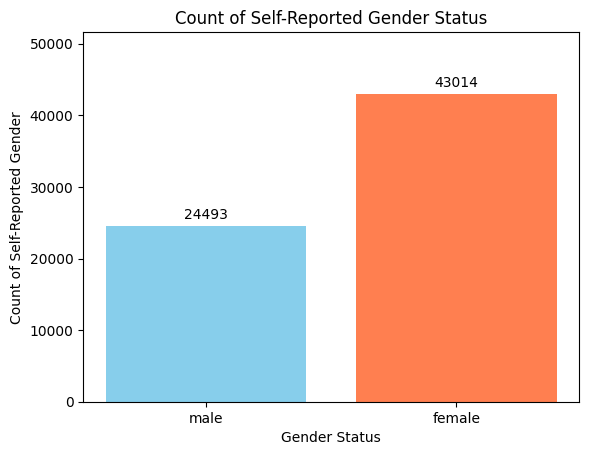

In [135]:

categories = ['male','female']
values = [24493, 43014]

fig, ax = plt.subplots()
colors = ['skyblue'] * len(categories)

# 2. Change the specific index you want to highlight (e.g., 'Cherries' at index 2)
colors[1] = 'coral'
# Create the bars and store the container in a variable
bars = ax.bar(categories, values, color=colors)

# Add the labels (the values) automatically
ax.bar_label(bars, padding=3)

# Create vertical bar chart

ax.set_ylim(0, max(values) * 1.2)


#plt.bar(categories, values, color=colors)

# Add labels and title
plt.xlabel('Gender Status')
plt.ylabel('Count of Self-Reported Gender')
plt.title('Count of Self-Reported Gender Status')

# Display the plot
plt.show()

Text(0.5, 1.0, 'Distribution of Ages')

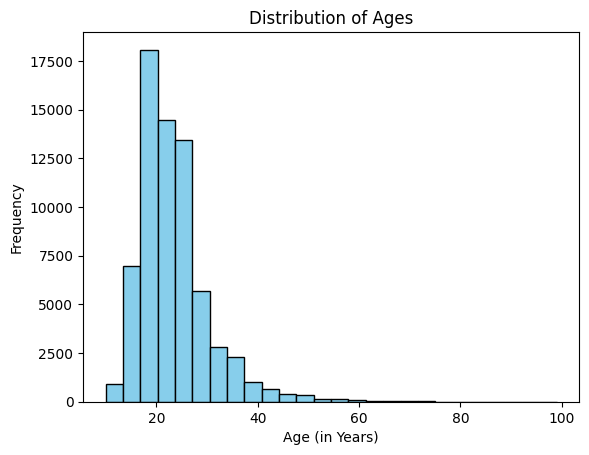

In [143]:
plt.hist(list(concatAdaptorsDf['age']), bins=26, edgecolor='black', color='skyblue')

# Add labels and title
plt.xlabel('Age (in Years)')
plt.ylabel('Frequency')
plt.title('Distribution of Ages')

References <br>

Beekhuizen, B. (2026). P4: Variant detection. [Jupyter
Notebook]. https://q.utoronto.ca/courses/421331.